In [1]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_community.tools import DuckDuckGoSearchRun
from langchain_core.tools import tool
from langgraph.graph.message import add_messages

from langchain_openai import ChatOpenAI
from langchain_core.messages import BaseMessage, HumanMessage


from dotenv import load_dotenv
from typing import TypedDict, Annotated
import requests
import random

In [2]:
load_dotenv(override=True)

True

In [3]:
# tools

search_tool = DuckDuckGoSearchRun(region='us-en')

@tool
def calculator_tool(first_num: float, second_num: float, operation: str) -> dict:
    """
    Tool to perform basic arithmetic calculation on two numbers
    supported opeartion - add, sub, mul, div
    """

    try:
        if operation=="add":
            result= first_num+second_num
        elif operation=="sub":
            result= first_num-second_num
        elif operation=="mul":
            result= first_num*second_num
        elif operation=="div":
            if second_num==0:
                return {'error': 'division by zero is not allowed'}
            result= first_num/second_num
        
        return {'operation':operation, 'first_num':first_num, 'second_num':second_num, 'result':result}
    
    except Exception as e:
        return {'Error': str(e)}
    
@tool
def get_stock_price(symbol:str) -> dict:
    """
    get the stock price of the given symbol eg "AAPL", "TSLA"
    from alpha vantage API with the given API KEY
    """
    r = requests.get(f"https://www.alphavantage.co/query?function=GLOBAL_QUOTE&symbol={symbol}&apikey=H7SWLKFQT5X0T9R2")
    return r.json()

In [4]:
llm = ChatOpenAI()

tools = [search_tool, calculator_tool, get_stock_price]
llm_with_tools = llm.bind_tools(tools)

In [5]:
# state
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]
    

In [6]:
# graph nodes
def chat_node(state: ChatState):
    """
    LLM node that may answer or request a tool call
    """
    messages = state['messages']
    response = llm_with_tools.invoke(messages)
    return {'messages': [response]}

tool_node = ToolNode(tools)

In [7]:
graph = StateGraph(ChatState)
graph.add_node('chat_node', chat_node)
graph.add_node('tools', tool_node)

In [8]:
graph.add_edge(START, "chat_node")
graph.add_conditional_edges('chat_node', tools_condition)

In [9]:
chatbot = graph.compile()

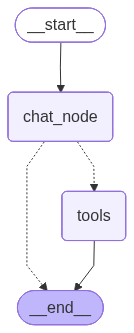

In [10]:
chatbot

In [11]:
output = chatbot.invoke({'messages': HumanMessage(content='Hello')})
output['messages'][-1].content

'Hello! How can I assist you today?'

In [12]:
output = chatbot.invoke({'messages': HumanMessage(content='What is the answer of 2*3')})
output['messages'][-1].content

'{"operation": "mul", "first_num": 2.0, "second_num": 3.0, "result": 6.0}'

In [13]:
output = chatbot.invoke({'messages': HumanMessage(content='What is the stock price of Nvidia?')})
output['messages'][-1].content

'{"Global Quote": {"01. symbol": "NVDA", "02. open": "176.0700", "03. high": "176.5100", "04. low": "171.1400", "05. price": "171.2400", "06. volume": "186152232", "07. latest trading day": "2026-03-26", "08. previous close": "178.6800", "09. change": "-7.4400", "10. change percent": "-4.1639%"}}'

In [14]:
output = chatbot.invoke({'messages': HumanMessage(content='How much money is needed to purchase 50 stocks of Nvidia?')})
output['messages'][-1].content

'{"Global Quote": {"01. symbol": "NVDA", "02. open": "176.0700", "03. high": "176.5100", "04. low": "171.1400", "05. price": "171.2400", "06. volume": "186152232", "07. latest trading day": "2026-03-26", "08. previous close": "178.6800", "09. change": "-7.4400", "10. change percent": "-4.1639%"}}'